In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
from scipy import stats
import statsmodels.formula.api as smf

import cellspec as spc

%matplotlib inline

In [2]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]

pal = {
    "AAVS_Clone_4_P1":colors[2],
    "AAVS_Clone_4_P2":colors[2],
    "AAVS_Clone_4_P3":colors[2],
    "AAVS_Clone_5_P1":colors[4],
    "AAVS_Clone_5_P2":colors[4],
    "AAVS_Clone_5_P3":colors[4],
    "AAVS_Clone_6_P1":colors[6],
    "AAVS_Clone_6_P2":colors[6],
    "AAVS_Clone_6_P3":colors[6],
    "PolE_Clone_4_P1":colors[0],
    "PolE_Clone_4_P2":colors[0],
    "PolE_Clone_4_P3":colors[0],
    "PolE_Clone_5_P1":colors[1],
    "PolE_Clone_5_P2":colors[1],
    "PolE_Clone_6_P1":colors[1],
    "PolE_Clone_6_P2":colors[3],
    "PolE_Clone_6_P3":colors[3]
}

In [3]:
# sns.set_style("white", {"axes.facecolor": (0, 0, 0, 0)}) 
# plt.style.use("dark_background")

In [4]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [5]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    # Axes lines
    "axes.linewidth": 1.5,

    # Tick marks
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# K562 Proliferation Data

data collected by Ian: [notion](https://www.notion.so/srivatsan-lab/PolE-K562-growth-rate-32ef40695c9580af8eb0ca58fd08d54f?source=copy_link)

In [6]:
cols = ['clone','Mutation',0,5,7,10]

WT = {
    'WT_clone1_rep1':['1','WT',3000,1.23e5,8.27e5,1.44e6],
    'WT_clone1_rep2':['1','WT',3000,1.11e5,1.30e6,1.82e6],
    'WT_clone2_rep1':['2','WT',3000,3.28e5,3.69e5,1.84e6],
    'WT_clone2_rep2':['2','WT',3000,1.11e5,6.98e5,8.21e5],
    'WT_clone3_rep1':['3','WT',3000,3.52e5,1.71e6,1.34e6],
    'WT_clone3_rep4':['3','WT',3000,5.04e5,1.52e6,2.38e6],
}

WT = pd.DataFrame.from_dict(WT,orient='index',columns=cols)

P286R = {
    'P286R_clone1_rep1':['1','P286R',3000,2.70e5,7.57e5,7.98e5],
    'P286R_clone1_rep2':['1','P286R',3000,7.04e4,3.17e5,9.21e5],
    'P286R_clone2_rep1':['2','P286R',3000,1.17e4,5.86e4,4.69e5],
    'P286R_clone2_rep2':['2','P286R',3000,2.93e4,3.52e4,8.33e5],
    'P286R_clone3_rep1':['3','P286R',3000,3.52e4,7.62e4,1.51e6],
    'P286R_clone3_rep2':['3','P286R',3000,7.03e4,6.54e4,7.21e5],
}

P286R = pd.DataFrame.from_dict(P286R,orient='index',columns=cols)


prolif = pd.concat([WT, P286R])

timepoints = np.array([0, 5, 7, 10])

In [7]:
# Melt wide -> long format for seaborn
prolif_long = prolif.melt(
    id_vars=['clone', 'Mutation'],
    value_vars=[0, 5, 7, 10],
    var_name='Day',
    value_name='Cell Count'
)

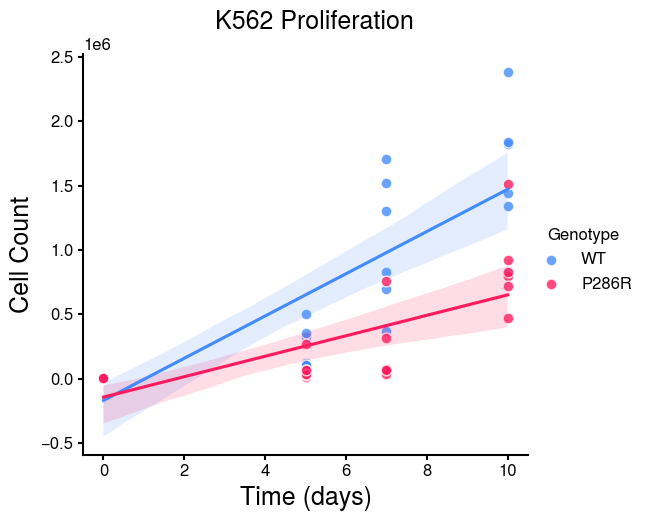

In [8]:
prolif_long['Day'] = pd.to_numeric(prolif_long['Day'])
prolif_long['Cell Count'] = pd.to_numeric(prolif_long['Cell Count'])
 
g = sns.lmplot(
    data=prolif_long,
    x='Day',
    y='Cell Count',
    hue='Mutation',
    # palette={'WT':'#E8E4F0','P286R':'#FF1B5E'}, # dark mode
    palette={'WT':'#438CFD','P286R':'#FF1B5E'},
    # markers=['o', 'X'],
    scatter_kws={'s': 60,'edgecolor': 'white'},
    height=5,
    aspect=1.1,
    ci=95,
    # legend=False
)
 
# g.set_axis_labels('Day', 'Cell Count')

plt.xlabel("Time (days)", fontsize=18)
plt.ylabel("Cell Count", fontsize=18)

g.figure.suptitle('K562 Proliferation',size=18, y=1.02)

g._legend.set_title('Genotype')

g.savefig('../results/K562_mut_accumulation/proliferation.png', bbox_inches='tight')

In [9]:
# =========================================================================
#    Log-linear regression: ln(N) = ln(N0) + r*t
#    Slope = r (ln-fold/day), r/ln2 = doublings/day
# =========================================================================
reg_rows = []
for sample, row in prolif.iterrows():
    counts = np.array([row[t] for t in timepoints], dtype=float)
    # Use all timepoints where count > 0
    mask = counts > 0
    t_fit = timepoints[mask]
    ln_counts = np.log(counts[mask])
    slope, intercept, r_value, p_value, std_err = stats.linregress(t_fit, ln_counts)
    reg_rows.append({
        'sample': sample,
        'clone': row['clone'],
        'Mutation': row['Mutation'],
        'r_per_day': slope,
        'doublings_per_day': slope / np.log(2),
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err,
    })
df_reg = pd.DataFrame(reg_rows)

In [10]:
print("\n" + "=" * 80)
print("LOG-LINEAR REGRESSION (all timepoints)")
print("   ln(N) ~ r * t + intercept")
print("=" * 80)
print(df_reg.to_string(index=False))


LOG-LINEAR REGRESSION (all timepoints)
   ln(N) ~ r * t + intercept
           sample clone Mutation  r_per_day  doublings_per_day  r_squared  p_value  std_err
   WT_clone1_rep1     1       WT   0.648189           0.935140   0.952912 0.023828 0.101887
   WT_clone1_rep2     1       WT   0.681844           0.983692   0.939076 0.030941 0.122805
   WT_clone2_rep1     2       WT   0.636909           0.918865   0.935108 0.032990 0.118639
   WT_clone2_rep2     2       WT   0.596652           0.860787   0.924414 0.038535 0.120641
   WT_clone3_rep1     3       WT   0.652719           0.941674   0.863906 0.070535 0.183188
   WT_clone3_rep4     3       WT   0.694772           1.002344   0.902077 0.050222 0.161863
P286R_clone1_rep1     1    P286R   0.588150           0.848521   0.870417 0.067039 0.160466
P286R_clone1_rep2     1    P286R   0.588367           0.848834   0.985278 0.007388 0.050856
P286R_clone2_rep1     2    P286R   0.500220           0.721665   0.934683 0.033210 0.093503
P286R_clone

In [11]:
# =========================================================================
# SIMPLE 6-REP SUMMARY + WELCH'S T-TEST
# Treating each replicate as independent (n=6 per genotype)
# =========================================================================
print("\n" + "=" * 80)
print("SIMPLE SUMMARY: 6 replicates per genotype (pooling across clones)")
print("=" * 80)
 
for mut in ['WT', 'P286R']:
    vals = df_reg.loc[df_reg['Mutation'] == mut, 'r_per_day'].values
    n = len(vals)
    m = vals.mean()
    s = vals.std(ddof=1)
    sem = s / np.sqrt(n)
    ci95 = sem * stats.t.ppf(0.975, df=n - 1)
    print(f"\n{mut} (n={n}):")
    print(f"  mean r    = {m:.4f} ln-fold/day  ({m / np.log(2):.4f} doublings/day)")
    print(f"  std       = {s:.4f}")
    print(f"  SEM       = {sem:.4f}")
    print(f"  95% CI    = [{m - ci95:.4f}, {m + ci95:.4f}]")
 
wt_r = df_reg.loc[df_reg['Mutation'] == 'WT', 'r_per_day'].values
p286r_r = df_reg.loc[df_reg['Mutation'] == 'P286R', 'r_per_day'].values
t_stat, p_val = stats.ttest_ind(wt_r, p286r_r, equal_var=False)
diff = wt_r.mean() - p286r_r.mean()
print(f"\nWelch's t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Difference in means: {diff:.4f} ln-fold/day ({diff / np.log(2):.4f} doublings/day)")


SIMPLE SUMMARY: 6 replicates per genotype (pooling across clones)

WT (n=6):
  mean r    = 0.6518 ln-fold/day  (0.9404 doublings/day)
  std       = 0.0347
  SEM       = 0.0142
  95% CI    = [0.6154, 0.6883]

P286R (n=6):
  mean r    = 0.5537 ln-fold/day  (0.7988 doublings/day)
  std       = 0.0420
  SEM       = 0.0171
  95% CI    = [0.5096, 0.5977]

Welch's t-test: t = 4.415, p = 0.0014
Difference in means: 0.0982 ln-fold/day (0.1416 doublings/day)


**Mean and SEM of doublings/day.**

$$\bar{d}_{WT} = \frac{0.9351 + 0.9837 + 0.9189 + 0.8608 + 0.9417 + 1.0023}{6} = 0.9404$$

$$s_{WT} = \sqrt{\frac{\sum(d_i - \bar{d})^2}{n-1}} = 0.0501$$

$$\text{SEM}_{WT} = \frac{s}{\sqrt{n}} = \frac{0.0501}{\sqrt{6}} = 0.0204$$

For P286R: $\bar{d} = 0.7988$, $s = 0.0605$, SEM = $0.0247$.

**Doublings per passage = $\bar{d} \times 21$ days.**

$$\text{WT: } 0.9404 \times 21 = 19.7 \text{ doublings}$$

$$\text{P286R: } 0.7988 \times 21 = 16.8 \text{ doublings}$$

**95% CI on doublings per passage.**

The CI on $\bar{d}$ is:

$$\bar{d} \pm t_{0.975,\, df=5} \times \text{SEM}$$

where $t_{0.975, 5} = 2.571$. Multiplying by 21 days scales everything linearly:

$$\text{CI}_{\text{passage}} = t \times \text{SEM} \times 21$$

For WT:

$$2.571 \times 0.0204 \times 21 = 1.1$$

$$19.7 \pm 1.1 \quad \Rightarrow \quad (18.6, \; 20.9)$$

For P286R:

$$2.571 \times 0.0247 \times 21 = 1.3$$

$$16.8 \pm 1.3 \quad \Rightarrow \quad (15.4, \; 18.1)$$

**3 passages — multiply by 3.**

$$\text{WT: } 59.2 \pm 3.3 \quad (55.9, \; 62.6)$$

$$\text{P286R: } 50.3 \pm 4.0 \quad (46.3, \; 54.3)$$


In [12]:
doublings_per_passage = {
    'WT':[19.7,1.1],
    'P286R':[16.8,1.3]
}

# Load Data

In [13]:
# adata = spc.pp.load_vcf('../data/K562_mut_accumulation/K562_mut_accumulation_joint.vcf.gz')
# adata

### Save adata for fast reloading:

In [14]:
# adata.write_h5ad('../results/K562_mut_accumulation/K562_mut_accumulation_raw.h5ad')

### Load adata from h5ad

In [15]:
adata = ad.read_h5ad('../results/K562_mut_accumulation/K562_mut_accumulation_raw.h5ad')

### Setup

In [16]:
obs = {
    "AAVS_Clone_4_P1":["WT","C4",1],
    "AAVS_Clone_4_P2":["WT","C4",2],
    "AAVS_Clone_4_P3":["WT","C4",3],
    "AAVS_Clone_5_P1":["WT","C5",1],
    "AAVS_Clone_5_P2":["WT","C5",2],
    "AAVS_Clone_5_P3":["WT","C5",3],
    "AAVS_Clone_6_P1":["WT","C6",1],
    "AAVS_Clone_6_P2":["WT","C6",2],
    "AAVS_Clone_6_P3":["WT","C6",3],
    "PolE_Clone_4_P1":["P286R","C4",1],
    "PolE_Clone_4_P2":["P286R","C4",2],
    "PolE_Clone_4_P3":["P286R","C4",3],
    "PolE_Clone_5_P1":["P286R","C5",1],
    "PolE_Clone_5_P2":["P286R","C5",2],
    "PolE_Clone_6_P1":["P286R","C6",1],
    "PolE_Clone_6_P2":["P286R","C6",2],
    "PolE_Clone_6_P3":["P286R","C6",3],
}
adata.obs = pd.DataFrame.from_dict(obs, orient='index', columns=['Mutation','Replicate','Split'])

In [17]:
## Filter out non snps
spc.pp.filter_to_snps(adata, inplace=True)

In [18]:
spc.pp.annotate_contexts(adata, fasta_path='/shared/biodata/reference/GATK/hg38/Homo_sapiens_assembly38.fasta')
adata.var

Annotating trinuc contexts: 100%|██████████| 5606780/5606780 [01:04<00:00, 87210.42 sites/s] 


,chrom,pos,anc,der,trinuc_type
chr1-10164-A>T,chr1,10164,TAA,TTA,TTA>TAA
chr1-10177-A>C,chr1,10177,AAC,ACC,GTT>GGT
chr1-10247-T>C,chr1,10247,CTA,CCA,CTA>CCA
chr1-10250-A>C,chr1,10250,AAC,ACC,GTT>GGT
chr1-10257-A>C,chr1,10257,AAC,ACC,GTT>GGT
...,...,...,...,...,...
chrY-56887491-C>A,chrY,56887491,CCT,CAT,CCT>CAT
chrY-56887503-G>T,chrY,56887503,GGG,GTG,CCC>CAC
chrY-56887530-A>C,chrY,56887530,CAT,CCT,ATG>AGG
chrY-56887837-G>A,chrY,56887837,AGA,AAA,TCT>TTT


# Basic Stats
- depth
- mutations per sample
- VAF in bulk

In [19]:
adata.var['tot_depth_bulk'] = np.ravel(adata.layers['DP'].sum(axis=0))

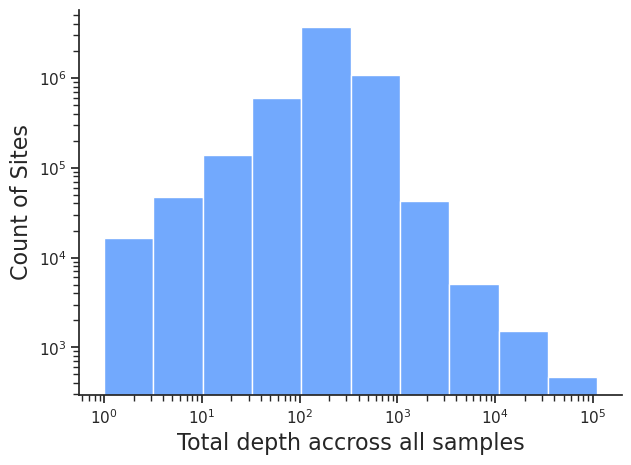

In [20]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var, x='tot_depth_bulk', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("Total depth accross all samples", fontsize=16)
plt.ylabel("Count of Sites", fontsize=16)
f.savefig('../results/K562_mut_accumulation/depth_hist.png')

In [21]:
spc.tl.compute_bulk_vaf(adata,
                        target_dp=100
                       )

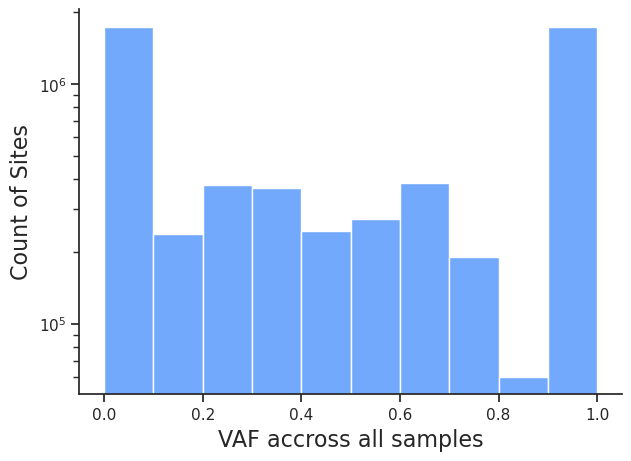

In [22]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(adata.var, x='bulk_vaf', 
             alpha=0.75,
             color = colors[2],
             linewidth=1,
             ax=ax,
             # log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("VAF accross all samples", fontsize=16)
plt.ylabel("Count of Sites", fontsize=16)
f.savefig('../results/K562_mut_accumulation/bulked_vaf.png')

### Filter ancestral variatns (high frequency in bulk population)

In [23]:
adata = adata[:,adata.var['bulk_vaf']<0.15].copy()

### Per Sample VAF

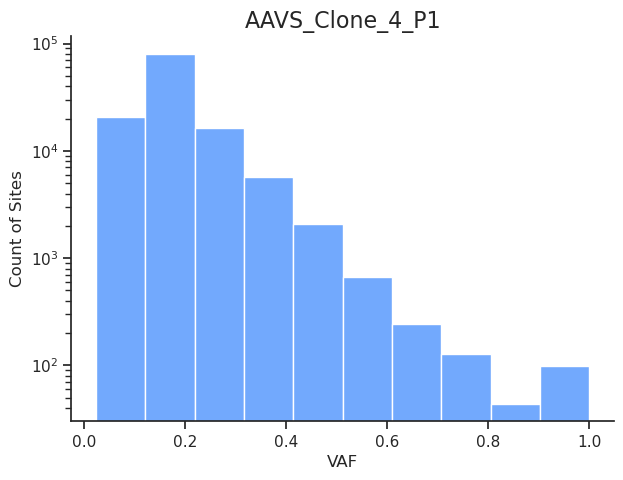

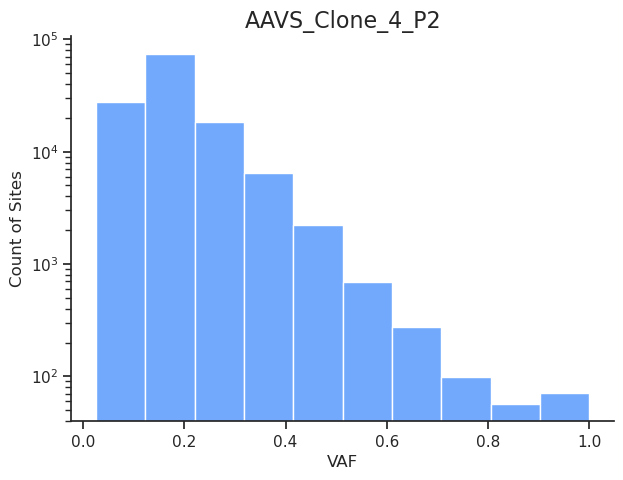

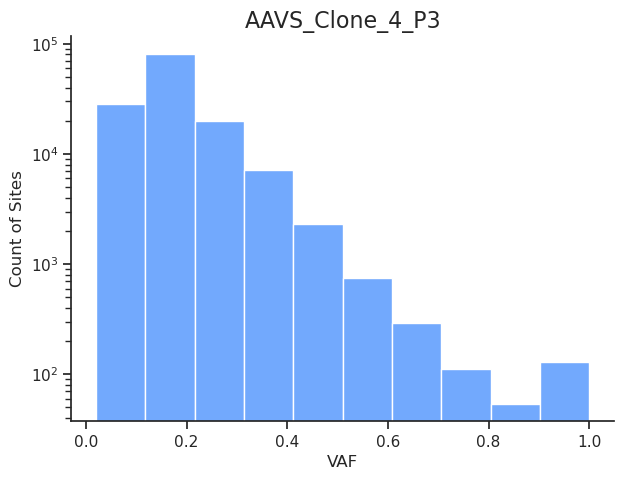

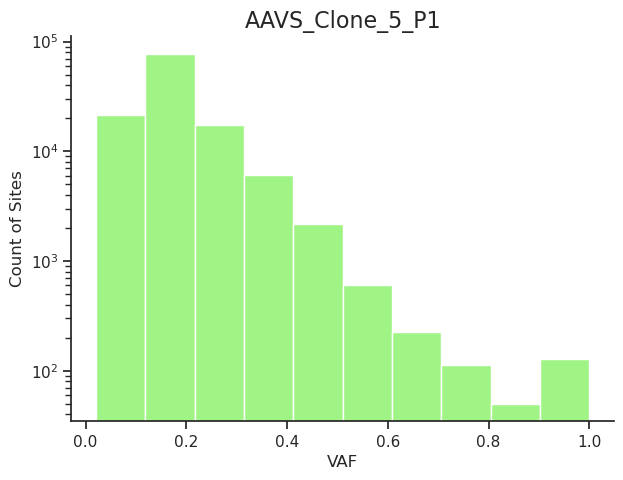

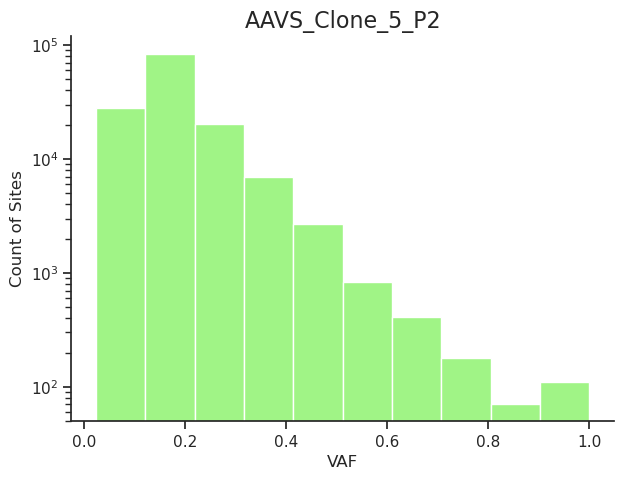

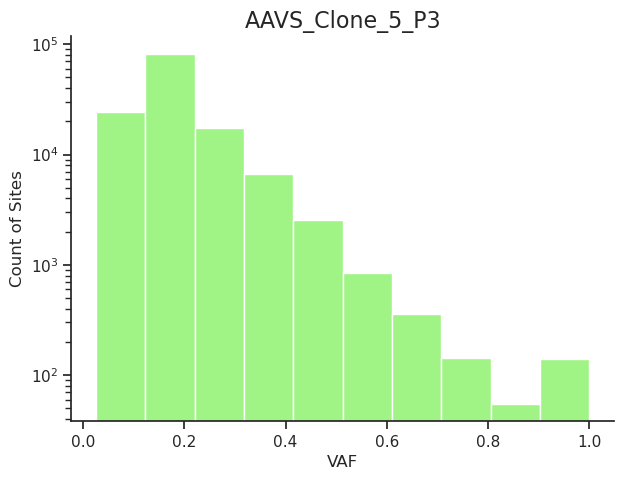

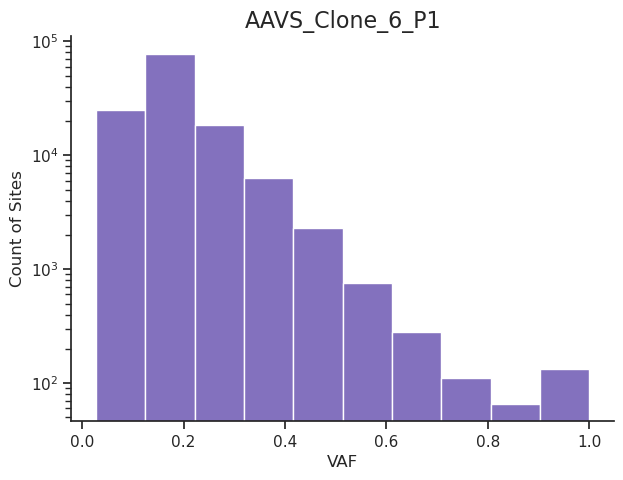

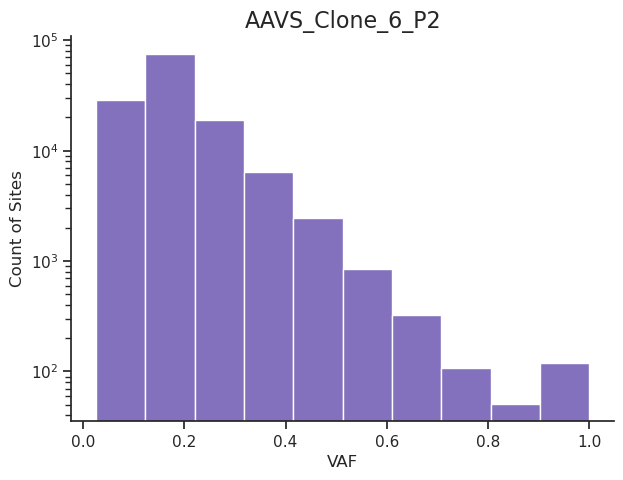

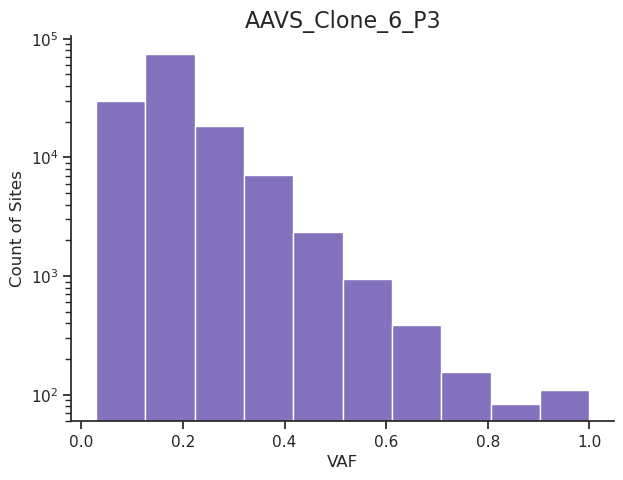

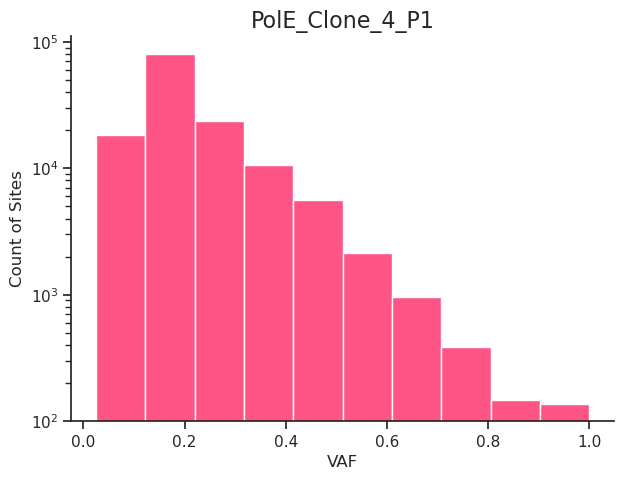

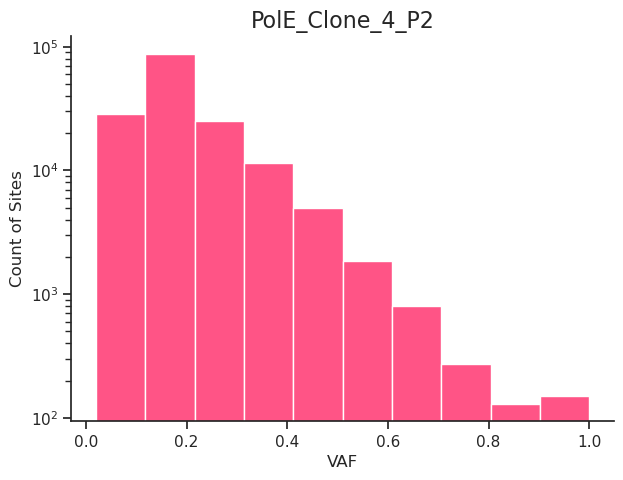

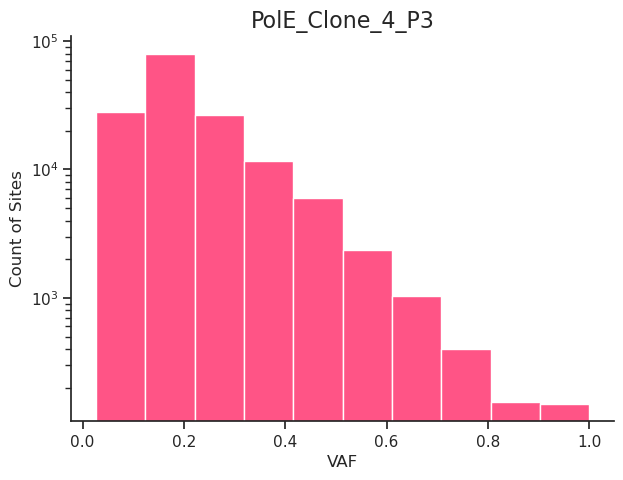

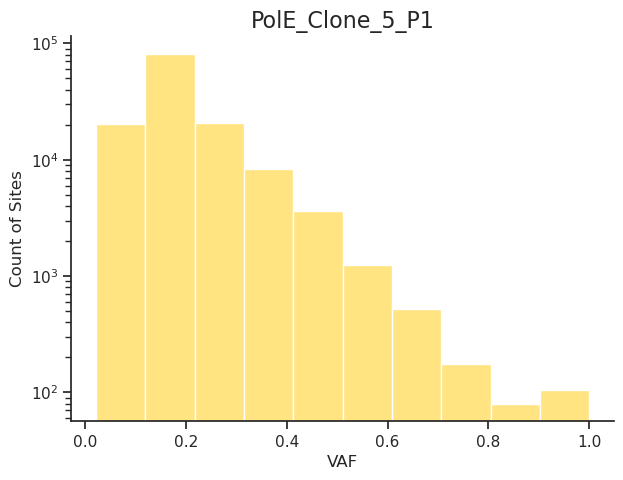

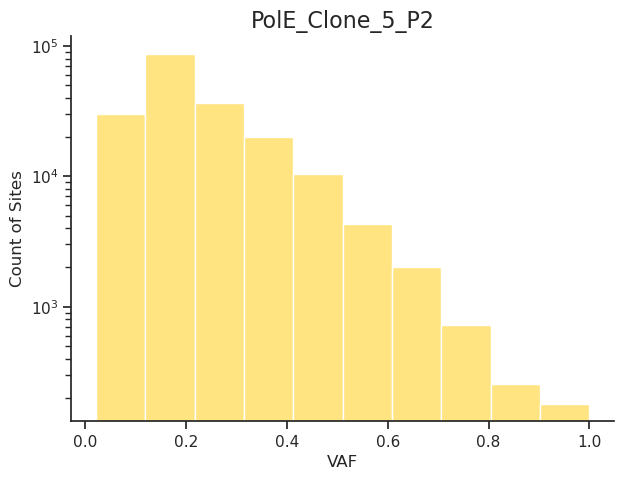

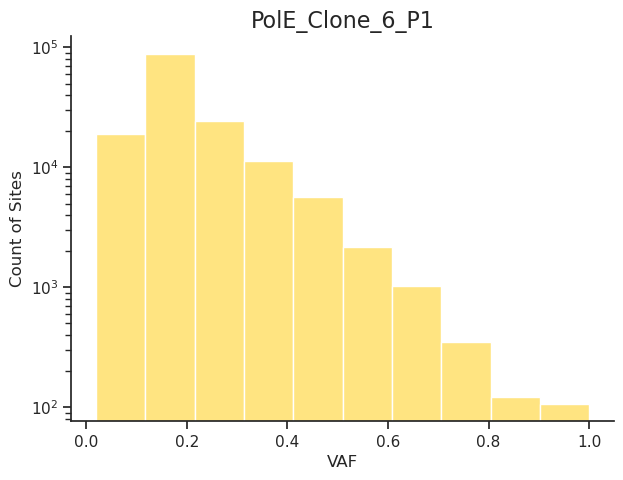

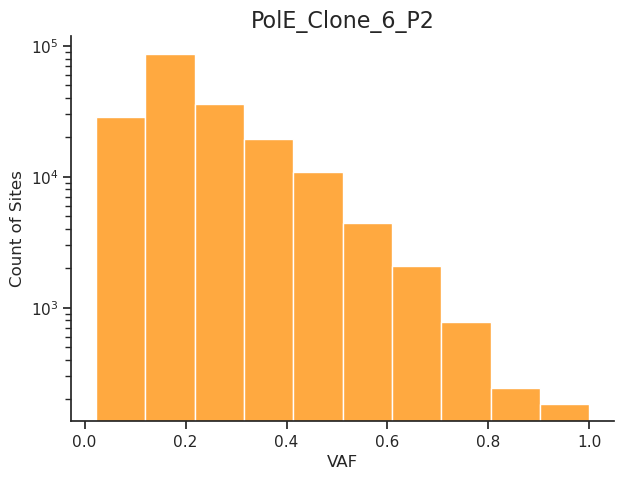

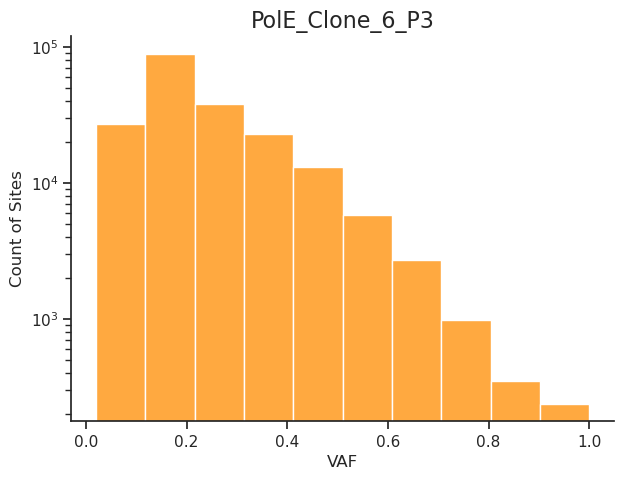

In [24]:
for sample in adata.obs.index:
    sub = adata[sample,:].copy()
    
    spc.pp.filter_by_coverage(sub, min_depth=10, max_depth=100)
    
    sub = sub[:,sub.layers['AD']>1].copy()
    
    vaf = pd.Series(index=sub.var.index, 
                    data=spc.utils.context.compute_vaf(sub.layers['AD'].toarray()[0],sub.layers['DP'].toarray()[0],100)
                   )
    
    high_vaf=vaf>0.15
    
    adata.var[f"{sample}_high_vaf"]=high_vaf.reindex(adata.var_names, fill_value=False)
    
    sub.var['vaf'] = vaf
    
    sns.set_theme(style="ticks")
    f, ax = plt.subplots(figsize=(7, 5))
    sns.despine(f)
    sns.histplot(sub.var, x='vaf', 
                 alpha=0.75,
                 color = pal[sample],
                 linewidth=1,
                 ax=ax,
                 # log_scale=True,
                 bins=10
                )
    ax.set_yscale('log')
    plt.xlabel("VAF", fontsize=12)
    plt.ylabel("Count of Sites", fontsize=12)
    plt.title(sample, fontsize=16)
    plt.show()

# Accumulated High Frequency mutations

In [110]:
lineages = {
    'P286R_C4': ["PolE_Clone_4_P1","PolE_Clone_4_P2","PolE_Clone_4_P3"],
    'P286R_C5': ["PolE_Clone_5_P1","PolE_Clone_5_P2"],
    'P286R_C6': ["PolE_Clone_6_P1","PolE_Clone_6_P2","PolE_Clone_6_P3"],
    'WT_C4': ["AAVS_Clone_4_P1","AAVS_Clone_4_P2","AAVS_Clone_4_P3"],
    'WT_C5': ["AAVS_Clone_5_P1","AAVS_Clone_5_P2","AAVS_Clone_5_P3"],
    'WT_C6': ["AAVS_Clone_6_P1","AAVS_Clone_6_P2","AAVS_Clone_6_P3"],
}

In [111]:
accumulated_mutations = {}

for lineage_name, samples in lineages.items():
    if len(samples)==3:
        s1 = set(adata.var[adata.var[f"{samples[0]}_high_vaf"]==True].index)#-high_vaf
        s2 = set(adata.var[adata.var[f"{samples[1]}_high_vaf"]==True].index)#-high_vaf
        s3 = set(adata.var[adata.var[f"{samples[2]}_high_vaf"]==True].index)#-high_vaf

        split_0 = s1.intersection(s2, s3)
        split_1 = s2.intersection(s3) - split_0
        split_2 = s3 - split_1

        count_0 = len(split_0)
        count_1 = len(split_1)
        count_2 = len(split_2)
        
        accumulated_mutations[lineage_name] = [count_0, count_0+count_1, count_0+count_1+count_2]
        
    elif len(samples)==2:
        s1 = set(adata.var[adata.var[f"{samples[0]}_high_vaf"]==True].index)#-high_vaf
        s2 = set(adata.var[adata.var[f"{samples[1]}_high_vaf"]==True].index)#-high_vaf

        split_0 = s1.intersection(s2)
        split_1 = s2 - split_0

        count_0 = len(split_0)
        count_1 = len(split_1)
        
        accumulated_mutations[lineage_name] = [count_0, count_0+count_1, None]
    

accumulated_mutations = pd.DataFrame.from_dict(accumulated_mutations, orient='index', columns=['split_1', 'split_2', 'split_3'])
accumulated_mutations

,split_1,split_2,split_3
P286R_C4,6179,27565,110642.0
P286R_C5,14681,134633,NaN
P286R_C6,18487,51869,164399.0
WT_C4,5805,15526,91545.0
WT_C5,5852,15402,92573.0
WT_C6,6478,15677,90666.0


In [112]:
time_series = accumulated_mutations.reset_index().melt(
    id_vars='index',
    var_name='split',
    value_name='accumulated_mutations'
)
time_series.rename(columns={'index': 'lineage'}, inplace=True)

split_to_passage = {'split_0': 0, 'split_1': 1, 'split_2': 2, 'split_3': 3}

time_series['passage'] = time_series['split'].map(split_to_passage)

time_series['genotype'] = time_series['lineage'].apply(
    lambda x: 'P286R' if x.startswith('P286R') else 'WT'
)

time_series = time_series.dropna()
time_series

,lineage,split,accumulated_mutations,passage,genotype
0,P286R_C4,split_1,6179.0,1,P286R
1,P286R_C5,split_1,14681.0,1,P286R
2,P286R_C6,split_1,18487.0,1,P286R
3,WT_C4,split_1,5805.0,1,WT
4,WT_C5,split_1,5852.0,1,WT
5,WT_C6,split_1,6478.0,1,WT
6,P286R_C4,split_2,27565.0,2,P286R
7,P286R_C5,split_2,134633.0,2,P286R
8,P286R_C6,split_2,51869.0,2,P286R
9,WT_C4,split_2,15526.0,2,WT


In [116]:
%matplotlib inline

Text(52.41140625, 0.5, 'Accumulated SBS')

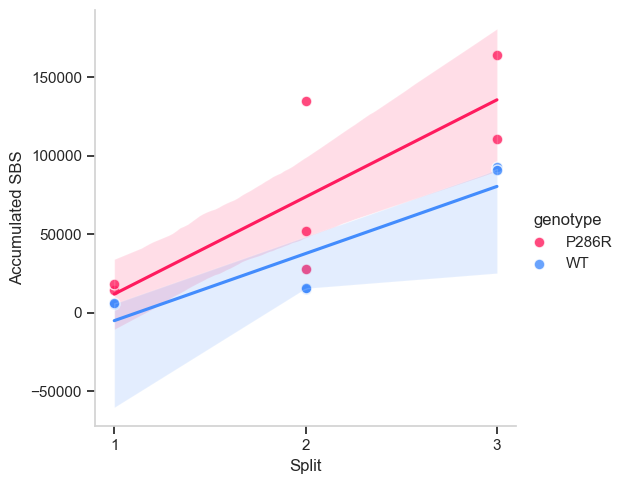

In [118]:
## Plot
g = sns.lmplot(time_series, x='passage',y='accumulated_mutations',
               palette={'WT':'#438CFD','P286R':'#FF1B5E'},
               hue='genotype',
               scatter_kws={'s': 60,'edgecolor': 'white'},
               height=5,
               aspect=1.1,
               ci=95,
        )

new_ticks = [1,2,3]
new_labels = ['1','2','3']
g.set(xticks=new_ticks, xticklabels=new_labels)
# plt.ylim(-19000,100000)
plt.xlabel("Split", fontsize=12)
plt.ylabel("Accumulated SBS", fontsize=12)

In [114]:
def cum_doublings(row):
    mut = row.genotype
    split = row.passage
    return [doublings_per_passage[mut][0], doublings_per_passage[mut][1], doublings_per_passage[mut][0]*split,doublings_per_passage[mut][1]*split]

In [115]:
time_series[['doublings_per_passage', 'doublings_per_passage_SE', 'cumulative_doublings', 'cumulative_doublings_SE']] = time_series.apply(cum_doublings, axis=1, result_type='expand')
time_series['accumulated_mutations_norm'] = time_series['accumulated_mutations'] / time_series['cumulative_doublings']
time_series

,lineage,split,accumulated_mutations,passage,genotype,doublings_per_passage,doublings_per_passage_SE,cumulative_doublings,cumulative_doublings_SE,accumulated_mutations_norm
0,P286R_C4,split_1,6179.0,1,P286R,16.8,1.3,16.8,1.3,367.797619
1,P286R_C5,split_1,14681.0,1,P286R,16.8,1.3,16.8,1.3,873.869048
2,P286R_C6,split_1,18487.0,1,P286R,16.8,1.3,16.8,1.3,1100.416667
3,WT_C4,split_1,5805.0,1,WT,19.7,1.1,19.7,1.1,294.670051
4,WT_C5,split_1,5852.0,1,WT,19.7,1.1,19.7,1.1,297.055838
5,WT_C6,split_1,6478.0,1,WT,19.7,1.1,19.7,1.1,328.832487
6,P286R_C4,split_2,27565.0,2,P286R,16.8,1.3,33.6,2.6,820.386905
7,P286R_C5,split_2,134633.0,2,P286R,16.8,1.3,33.6,2.6,4006.934524
8,P286R_C6,split_2,51869.0,2,P286R,16.8,1.3,33.6,2.6,1543.720238
9,WT_C4,split_2,15526.0,2,WT,19.7,1.1,39.4,2.2,394.060914


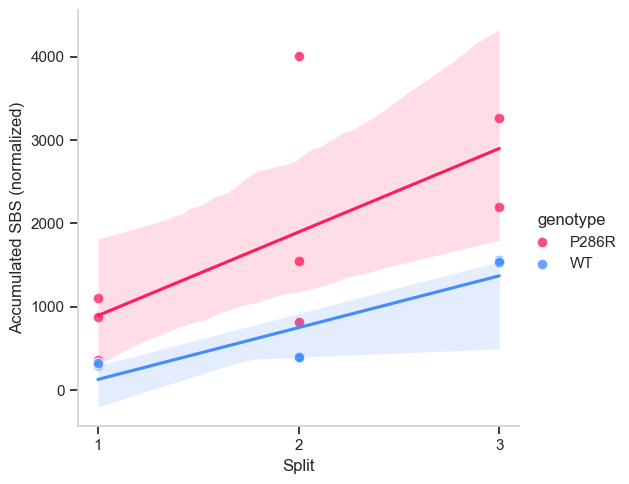

In [119]:
## Plot
g = sns.lmplot(time_series, x='passage',y='accumulated_mutations_norm',
               palette={'WT':'#438CFD','P286R':'#FF1B5E'},
               hue='genotype',
               scatter_kws={'s': 60,'edgecolor': 'white'},
               height=5,
               aspect=1.1,
               ci=95,
        )

new_ticks = [1,2,3]
new_labels = ['1','2','3']
g.set(xticks=new_ticks, xticklabels=new_labels)
# plt.ylim(-19000,100000)
plt.xlabel("Split", fontsize=12)
plt.ylabel("Accumulated SBS (normalized)", fontsize=12)

g.savefig('../results/K562_mut_accumulation/accumulated_mutations.png')
plt.show()

In [120]:
time_series['genotype'] = pd.Categorical(
    time_series['genotype'], 
    categories=['WT', 'P286R']  # WT first = WT is reference
)

# Random intercept + slope model
model = smf.mixedlm(
    "accumulated_mutations_norm ~ passage * genotype",
    data=time_series,
    groups="lineage",
    re_formula="~1"
)
result = model.fit()

print(str(result.summary()))

                    Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  accumulated_mutations_norm
No. Observations:    17       Method:              REML                      
No. Groups:          6        Scale:               348341.1534               
Min. group size:     2        Log-Likelihood:      -107.5557                 
Max. group size:     3        Converged:           Yes                       
Mean group size:     2.8                                                     
-----------------------------------------------------------------------------
                            Coef.    Std.Err.   z    P>|z|   [0.025   0.975] 
-----------------------------------------------------------------------------
Intercept                   -492.650  603.854 -0.816 0.415 -1676.181  690.881
genotype[T.P286R]            190.637  877.234  0.217 0.828 -1528.710 1909.984
passage                      621.486  240.950  2.579 0.010   149.233 1093.739
passag

In [43]:
# Extract key coefficients
print("\n" + "-"*70)
print("KEY COEFFICIENTS:")
print("-"*70)
print(f"WT baseline rate (Generation):           {result.fe_params['passage']:,.0f} mutations/passage")
print(f"P286R additional rate (Gen:Genotype):    {result.fe_params['passage:genotype[T.P286R]']:,.0f} mutations/passage")
print(f"P286R total rate:                        {result.fe_params['passage'] + result.fe_params['passage:genotype[T.P286R]']:,.0f} mutations/passage")
print(f"\nInteraction p-value: {result.pvalues['passage:genotype[T.P286R]']:.2e}")



----------------------------------------------------------------------
KEY COEFFICIENTS:
----------------------------------------------------------------------
WT baseline rate (Generation):           621 mutations/passage
P286R additional rate (Gen:Genotype):    976 mutations/passage
P286R total rate:                        1,597 mutations/passage

Interaction p-value: 1.55e-01


### Only `TCT>TAT` Mutations

In [74]:
accumulated_TCT_mutations = {}

for lineage_name, samples in lineages.items():
    if len(samples)==3:
        s1 = set(adata.var[(adata.var[f"{samples[0]}_high_vaf"]==True) & (adata.var['trinuc_type']=='TCT>TAT')].index)#-high_vaf
        s2 = set(adata.var[(adata.var[f"{samples[1]}_high_vaf"]==True) & (adata.var['trinuc_type']=='TCT>TAT')].index)#-high_vaf
        s3 = set(adata.var[(adata.var[f"{samples[2]}_high_vaf"]==True) & (adata.var['trinuc_type']=='TCT>TAT')].index)#-high_vaf

        split_0 = s1.intersection(s2, s3)
        split_1 = s2.intersection(s3) - split_0
        split_2 = s3 - split_1

        count_0 = len(split_0)
        count_1 = len(split_1)
        count_2 = len(split_2)
        
        accumulated_TCT_mutations[lineage_name] = [count_0, count_0+count_1, count_0+count_1+count_2]
        
    elif len(samples)==2:
        s1 = set(adata.var[(adata.var[f"{samples[0]}_high_vaf"]==True) & (adata.var['trinuc_type']=='TCT>TAT')].index)#-high_vaf
        s2 = set(adata.var[(adata.var[f"{samples[1]}_high_vaf"]==True) & (adata.var['trinuc_type']=='TCT>TAT')].index)#-high_vaf
        
        split_0 = s1.intersection(s2)
        split_1 = s2 - split_0

        count_0 = len(split_0)
        count_1 = len(split_1)
        
        accumulated_TCT_mutations[lineage_name] = [count_0, count_0+count_1, None]
    

accumulated_TCT_mutations = pd.DataFrame.from_dict(accumulated_TCT_mutations, orient='index', columns=['split_1', 'split_2', 'split_3'])
accumulated_TCT_mutations

,split_1,split_2,split_3
P286R_C4,230,4561,9478.0
P286R_C5,445,20047,NaN
P286R_C6,5168,14355,31285.0
WT_C4,177,370,1548.0
WT_C5,186,371,1470.0
WT_C6,215,377,1576.0


In [82]:
time_series_TCT = accumulated_TCT_mutations.reset_index().melt(
    id_vars='index',
    var_name='split',
    value_name='SBS10a'
)
time_series_TCT.rename(columns={'index': 'lineage'}, inplace=True)

split_to_passage = {'split_0': 0, 'split_1': 1, 'split_2': 2, 'split_3': 3}

time_series_TCT['passage'] = time_series_TCT['split'].map(split_to_passage)

time_series_TCT['genotype'] = time_series_TCT['lineage'].apply(
    lambda x: 'P286R' if x.startswith('P286R') else 'WT'
)

time_series_TCT = time_series_TCT.dropna()
time_series['SBS10a'] = time_series_TCT['SBS10a']

In [99]:
## Plot
g = sns.lmplot(time_series, x='passage',y='SBS10a',
               palette={'WT':'#438CFD','P286R':'#FF1B5E'},
               hue='genotype',
               scatter_kws={'s': 60,'edgecolor': 'white'},
               height=5,
               aspect=1.1,
               ci=95,
        )

new_ticks = [1,2,3]
new_labels = ['1','2','3']
g.set(xticks=new_ticks, xticklabels=new_labels)
# plt.ylim(-19000,100000)
plt.xlabel("Split", fontsize=12)
plt.ylabel("SBS10a activity", fontsize=12)

g.savefig('../results/K562_mut_accumulation/accumulated_SBS10a.png')
plt.show()

In [107]:
time_series['genotype'] = pd.Categorical(
    time_series['genotype'], 
    categories=['WT', 'P286R']  # WT first = WT is reference
)

# Random intercept + slope model
model = smf.mixedlm(
    "SBS10a ~ passage * genotype",
    data=time_series,
    groups="lineage",
    re_formula="~1"
)
result = model.fit()

result.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
=================================================================================
Model:                    MixedLM        Dependent Variable:        SBS10a       
No. Observations:         17             Method:                    REML         
No. Groups:               6              Scale:                     14725227.8424
Min. group size:          2              Log-Likelihood:            -132.3944    
Max. group size:          3              Converged:                 Yes          
Mean group size:          2.8                                                    
---------------------------------------------------------------------------------
                             Coef.     Std.Err.   z    P>|z|   [0.025     0.975] 
---------------------------------------------------------------------------------
Intercept                     -639.778 4130.184 -0.155 0.877  -8734.789  7455.234
genotype[T.P286R]            -6846.288 5956.697 -1.149 0.250 -18521.199  4828.623
passage                        669.333 1566.590  0.427 0.669  -2401.127  3739.794
passage:genotype[T.P286R]     9165.966 2382.529  3.847 0.000   4496.294 13835.637
lineage Var               16816392.147 4848.939                                  
=================================================================================

"""

In [108]:
print(str(result.summary()))

                      Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        SBS10a       
No. Observations:         17             Method:                    REML         
No. Groups:               6              Scale:                     14725227.8424
Min. group size:          2              Log-Likelihood:            -132.3944    
Max. group size:          3              Converged:                 Yes          
Mean group size:          2.8                                                    
---------------------------------------------------------------------------------
                             Coef.     Std.Err.   z    P>|z|   [0.025     0.975] 
---------------------------------------------------------------------------------
Intercept                     -639.778 4130.184 -0.155 0.877  -8734.789  7455.234
genotype[T.P286R]            -6846.288 5956.697 -1.149 0.250 -18521.199  4828.623
passage                        669.333

In [109]:
# Extract key coefficients
print("\n" + "-"*70)
print("KEY COEFFICIENTS:")
print("-"*70)
print(f"WT baseline rate (Generation):           {result.fe_params['passage']:,.0f} mutations/passage")
print(f"P286R additional rate (Gen:Genotype):    {result.fe_params['passage:genotype[T.P286R]']:,.0f} mutations/passage")
print(f"P286R total rate:                        {result.fe_params['passage'] + result.fe_params['passage:genotype[T.P286R]']:,.0f} mutations/passage")
print(f"\nInteraction p-value: {result.pvalues['passage:genotype[T.P286R]']:.2e}")



----------------------------------------------------------------------
KEY COEFFICIENTS:
----------------------------------------------------------------------
WT baseline rate (Generation):           669 mutations/passage
P286R additional rate (Gen:Genotype):    9,166 mutations/passage
P286R total rate:                        9,835 mutations/passage

Interaction p-value: 1.19e-04


### SBS10a mutation rate


**Per-division mutation rate:**

$$\mu = \frac{M}{D}$$

where M = mutations per passage (from the mixed model) and D = doublings per passage (from the proliferation assay).

For P286R:

$$M = \beta_{passage} + \beta_{interaction} = 669.3 + 9166.0 = 9835.3$$

$$D = 16.8$$

$$\mu = \frac{9835.3}{16.8} = 585.4 \text{ mutations per division}$$

**SE via the delta method:**

Since M and D come from independent experiments (WGS mutation counting vs. proliferation assay), they're uncorrelated. For a ratio of independent quantities, the delta method gives:

$$SE(\mu) = |\mu| \sqrt{\frac{SE(M)^2}{M^2} + \frac{SE(D)^2}{D^2}}$$

The SE on M is approximate — since M is the sum of two model coefficients ($\beta_{passage} + \beta_{interaction}$), the exact SE would be:

$$SE(M) = \sqrt{SE(\beta_p)^2 + SE(\beta_i)^2 + 2 \cdot \text{Cov}(\beta_p, \beta_i)}$$

I assumed zero covariance, giving:

$$SE(M) = \sqrt{1566.6^2 + 2382.5^2} = \sqrt{2454225 + 5676436} = \sqrt{8130661} = 2851.4$$

Then:

$$SE(\mu) = |585.4| \sqrt{\frac{2851.4^2}{9835.3^2} + \frac{1.3^2}{16.8^2}}$$

$$= 585.4 \sqrt{\frac{8130486}{96733526} + \frac{1.69}{282.24}}$$

$$= 585.4 \sqrt{0.08406 + 0.00599}$$

$$= 585.4 \sqrt{0.09005}$$

$$= 585.4 \times 0.3001$$

$$= 175.7$$

**95% CI:**

$$\mu \pm 1.96 \times SE(\mu) = 585.4 \pm 1.96 \times 175.7 = 585.4 \pm 344.3$$

$$(241.1, \; 929.7)$$

Note: the relative contribution of doubling uncertainty to the total is small — $0.00599 / 0.09005 \approx 6.7\%$. The dominant source of uncertainty is the mutation count estimate from the mixed model. Also, if you can extract the covariance between $\beta_{passage}$ and $\beta_{interaction}$ from `result.cov_params()`, you'd get a more accurate $SE(M)$.

### save results

In [86]:
time_series.to_csv('../results/K562_mut_accumulation/mutation_accumulation.csv')

# Mutation Spectrum (all mutations)

In [41]:
spc.tl.compute_spectrum(adata)

Computing spectrum (key='spectrum'): 100%|██████████| 17/17 [00:04<00:00,  3.96cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
AAVS_Clone_4_P1,3395,2815,1311,2161,3166,2580,1334,2525,2936,2054,...,1618,1452,1172,1129,2133,1790,1403,1737,2227,2776
AAVS_Clone_4_P2,3511,2853,1350,2158,3195,2590,1318,2598,2953,2055,...,1657,1479,1156,1176,2170,1870,1419,1772,2263,2854
AAVS_Clone_4_P3,3477,2864,1359,2177,3177,2553,1333,2556,3022,2055,...,1658,1468,1176,1179,2107,1869,1432,1730,2281,2820
AAVS_Clone_5_P1,3368,2831,1326,2153,3092,2524,1273,2486,2935,2046,...,1569,1412,1157,1131,2107,1776,1385,1716,2201,2768
AAVS_Clone_5_P2,3464,2824,1330,2172,3116,2514,1293,2567,2935,2061,...,1650,1437,1171,1134,2115,1828,1396,1726,2216,2781
AAVS_Clone_5_P3,3381,2820,1309,2101,3141,2522,1279,2480,2906,2026,...,1625,1425,1136,1149,2082,1769,1383,1713,2234,2780
AAVS_Clone_6_P1,3442,2841,1344,2128,3128,2515,1315,2506,2958,2050,...,1653,1443,1166,1174,2093,1833,1380,1727,2225,2800
AAVS_Clone_6_P2,3476,2906,1364,2186,3218,2601,1341,2517,3002,2092,...,1647,1488,1186,1181,2140,1856,1407,1777,2278,2862
AAVS_Clone_6_P3,3509,2892,1377,2178,3163,2587,1339,2504,3001,2077,...,1659,1485,1179,1199,2133,1853,1428,1756,2297,2868
PolE_Clone_4_P1,3407,2843,1357,2250,3139,2534,1312,2822,2947,2053,...,1662,1610,1166,1172,2090,1830,1439,1761,2224,3321


In [46]:
adata.obsm['spectrum_spectrum'].to_csv('../results/K562_mut_accumulation/spectrum.csv')

In [33]:
spc.pl.spectrum(adata, groupby='Mutation', figsize=(18,9), 
                # normalize=True
                # transparent=True,
                outdir='../results/K562_mut_accumulation/'
               )


# Mutation Spectrum (high confidence de novo mutations)

In [65]:
for lineage_name, samples in lineages.items():
    if len(samples)==3:
        adata.var[f"{lineage_name}_mutations"] = adata.var[f"{samples[0]}_high_vaf"] | adata.var[f"{samples[1]}_high_vaf"] | adata.var[f"{samples[2]}_high_vaf"]
    elif len(samples)==2:
        adata.var[f"{lineage_name}_mutations"] = adata.var[f"{samples[0]}_high_vaf"] | adata.var[f"{samples[1]}_high_vaf"]

adata.var["P286R_mutations"] = adata.var['P286R_C4_mutations'] | adata.var['P286R_C5_mutations'] | adata.var['P286R_C6_mutations']
adata.var["WT_mutations"] = adata.var['WT_C4_mutations'] | adata.var['WT_C5_mutations'] | adata.var['WT_C6_mutations']

print(f"P286R mutation count: {adata.var['P286R_mutations'].sum()}")
print(f"WT mutation count: {adata.var['WT_mutations'].sum()}")


P286R mutation count: 636036
WT mutation count: 516622


In [66]:
adata_de_novo = adata[:,adata.var['P286R_mutations'] | adata.var['WT_mutations']].copy()

In [67]:
spc.tl.compute_spectrum(adata_de_novo)

Computing spectrum (key='spectrum'): 100%|██████████| 17/17 [00:02<00:00,  8.33cell/s]


,ACA>AAA,ACC>AAC,ACG>AAG,ACT>AAT,CCA>CAA,CCC>CAC,CCG>CAG,CCT>CAT,GCA>GAA,GCC>GAC,...,CTG>CGG,CTT>CGT,GTA>GGA,GTC>GGC,GTG>GGG,GTT>GGT,TTA>TGA,TTC>TGC,TTG>TGG,TTT>TGT
AAVS_Clone_4_P1,1552,952,464,1050,1585,1316,530,1511,1191,801,...,629,543,501,360,876,623,616,655,1024,1187
AAVS_Clone_4_P2,1701,997,498,1162,1513,1508,580,1847,1197,759,...,594,537,467,341,828,608,644,674,1005,1247
AAVS_Clone_4_P3,1851,957,527,1132,1608,1462,626,1790,1311,827,...,619,519,496,353,848,703,690,671,1023,1350
AAVS_Clone_5_P1,1737,986,522,1117,1446,1215,472,1445,1191,795,...,598,513,521,321,850,662,635,687,1009,1268
AAVS_Clone_5_P2,1919,1053,492,1173,1573,1531,593,1852,1312,880,...,604,533,527,384,840,663,702,697,1031,1358
AAVS_Clone_5_P3,1707,1037,486,1095,1570,1339,569,1553,1245,835,...,661,520,516,386,869,654,645,673,1045,1286
AAVS_Clone_6_P1,1694,951,503,1093,1488,1217,547,1465,1267,804,...,616,540,483,361,843,621,588,688,1000,1296
AAVS_Clone_6_P2,1659,1020,502,1137,1554,1346,569,1618,1269,866,...,604,533,498,352,825,648,596,704,1012,1292
AAVS_Clone_6_P3,1756,1004,506,1092,1468,1357,542,1592,1255,811,...,626,547,489,368,802,647,648,678,1003,1396
PolE_Clone_4_P1,1730,1027,527,1586,1606,1282,508,2486,1285,889,...,661,1138,491,377,802,710,1033,804,1060,4554


In [68]:
adata_de_novo.obsm['spectrum_spectrum'].to_csv('../results/K562_mut_accumulation/spectrum.csv')

In [69]:
spc.pl.spectrum(adata_de_novo, groupby='Mutation', figsize=(18,9), 
                # normalize=True
                # transparent=True,
                outdir='../results/K562_mut_accumulation/'
               )

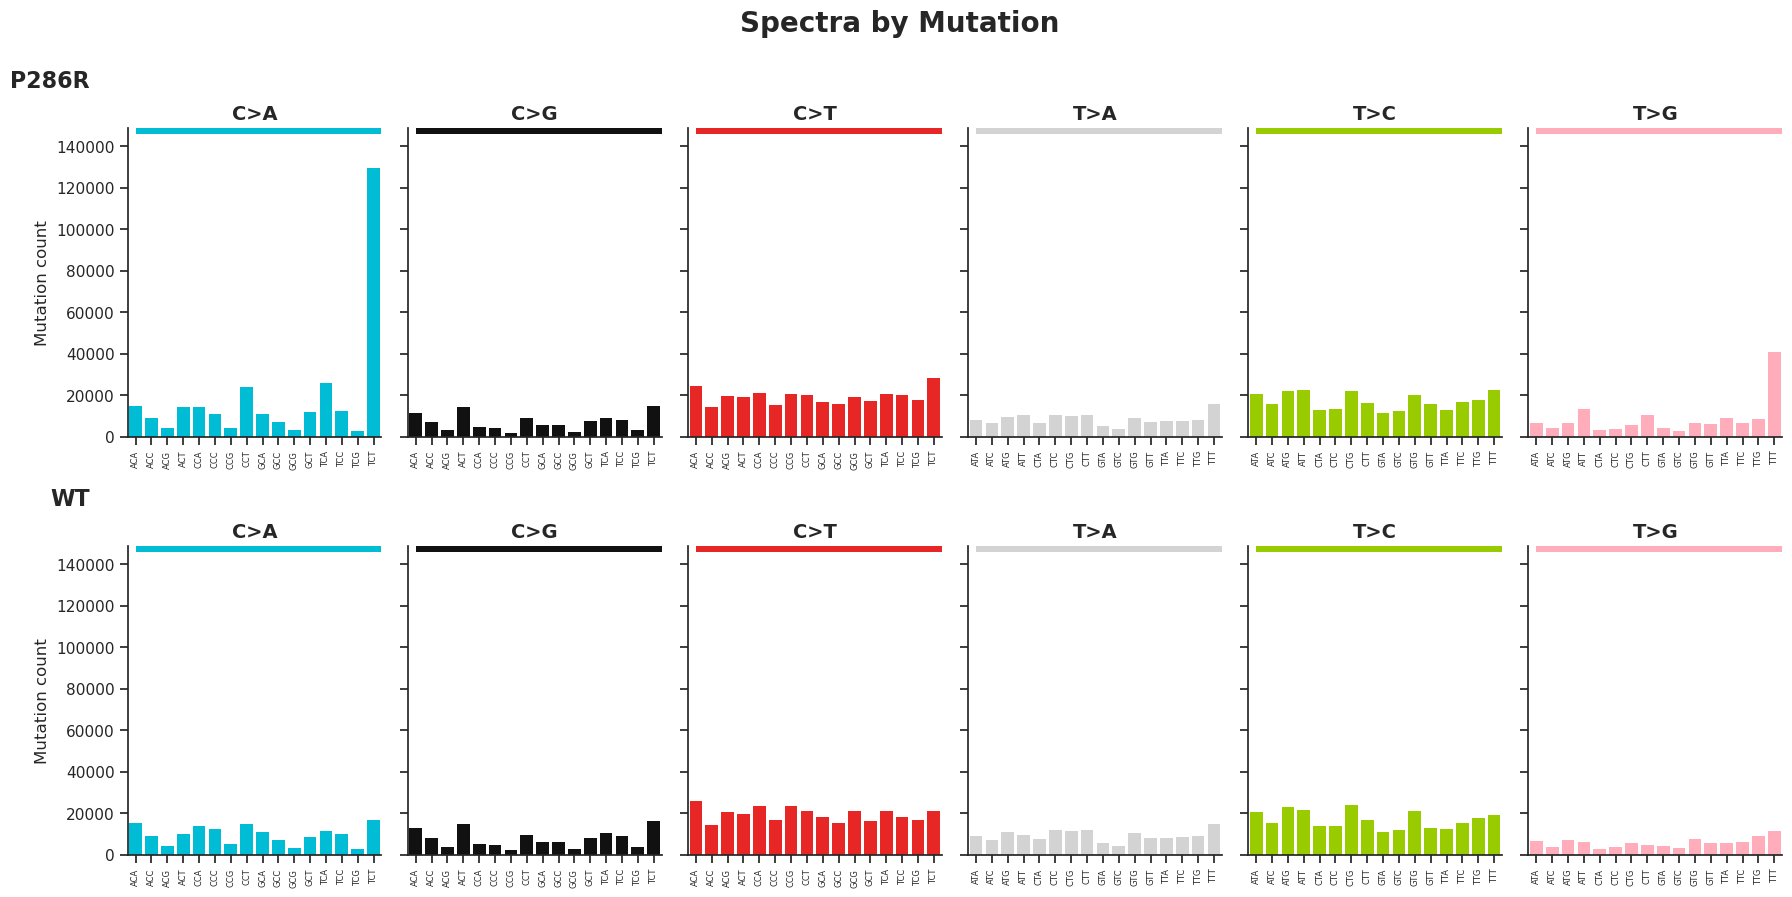

In [70]:
spc.pl.spectrum(adata_de_novo, groupby='Mutation', figsize=(18,9), 
                # normalize=True
                # transparent=True,
                # outdir='../results/K562_mut_accumulation/'
               )

# Signature Decomposition

In [90]:
spc.tl.fit_cosmic_signatures(adata_de_novo, groupby='Mutation', output_dir='../results/K562_mut_accumulation/sigprofiler')

Fitting COSMIC v3.4 signatures to spectrum 'spectrum'...
Aggregating spectrum by 'Mutation' using sum...
Created 2 aggregated samples from 2 unique groups
SigProfiler outputs will be saved to: ../results/K562_mut_accumulation/sigprofiler
Converted spectrum to SigProfiler format: ../results/K562_mut_accumulation/sigprofiler/input/matrix.txt
Analyzing 2 samples with 2390891 total mutations
Running SigProfilerAssignment (this may take a few minutes)...
Assigning COSMIC sigs or Signature Database ...... 





                                        ################ Sample 1 #################
############################# Initial Composition #################################### 
     SBS1     SBS2     SBS3  SBS4  SBS5     SBS6   SBS7a    SBS7b  SBS7c  \
0  5893.0  14347.0  34491.0   0.0   0.0  40701.0  2665.0  24194.0    0.0   

   SBS7d  ...  SBS90  SBS91  SBS92    SBS93  SBS94  SBS95    SBS96    SBS97  \
0  155.0  ...    0.0    0.0    0.0  17397.0    0.0    0.0  48918.0  17291.0   

   SB

[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:   13.9s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Parsing results...
Found 54 active signatures across 2 samples
Results stored in:
  - adata.uns['spectrum_Mutation_cosmic_fit']
  - adata.uns['spectrum_Mutation_cosmic_fit_proportions']
  - adata.uns['spectrum_Mutation_cosmic_fit_metadata']
  - adata.uns['cosmic_signatures']


In [96]:
adata_de_novo.uns['spectrum_Mutation_cosmic_fit_proportions'].loc['P286R'].sort_values(ascending=False)

SBS10a    0.130248
SBS39     0.081880
SBS37     0.068332
SBS8      0.063932
SBS46     0.051513
            ...   
SBS92     0.000000
SBS95     0.000000
SBS94     0.000000
SBS98     0.000000
SBS99     0.000000
Name: P286R, Length: 86, dtype: float64

In [97]:
adata_de_novo.uns['spectrum_Mutation_cosmic_fit_proportions'].loc['WT'].sort_values(ascending=False)

SBS37    0.100107
SBS8     0.095648
SBS39    0.087357
SBS3     0.086968
SBS54    0.055013
           ...   
SBS92    0.000000
SBS95    0.000000
SBS94    0.000000
SBS93    0.000000
SBS99    0.000000
Name: WT, Length: 86, dtype: float64

### Individual

In [91]:
spc.tl.fit_cosmic_signatures(adata_de_novo, output_dir='../results/K562_mut_accumulation/sigprofiler_ind')

Fitting COSMIC v3.4 signatures to spectrum 'spectrum'...
SigProfiler outputs will be saved to: ../results/K562_mut_accumulation/sigprofiler_ind
Converted spectrum to SigProfiler format: ../results/K562_mut_accumulation/sigprofiler_ind/input/matrix.txt
Analyzing 17 samples with 2390891 total mutations
Running SigProfilerAssignment (this may take a few minutes)...
Assigning COSMIC sigs or Signature Database ...... 





                                        ################ Sample 1 #################
############################# Initial Composition #################################### 
    SBS1    SBS2     SBS3  SBS4  SBS5    SBS6  SBS7a   SBS7b  SBS7c  SBS7d  \
0  664.0  1615.0  11408.0   0.0   0.0  8462.0   75.0  1814.0  108.0    0.0   

   ...  SBS90  SBS91  SBS92  SBS93  SBS94  SBS95   SBS96   SBS97  SBS98  SBS99  
0  ...    0.0    0.0    0.0    0.0    0.0    0.0  4436.0  2947.0  556.0    0.0  

[1 rows x 86 columns]
L2%:  0.10062326424822456
############################## Composi

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:  1.9min
[Parallel(n_jobs=1)]: Done  17 out of  17 | elapsed:  1.9min finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
Parsing results...
Found 60 active signatures across 17 samples
Results stored in:
  - adata.obsm['spectrum_cosmic_fit']
  - adata.obsm['spectrum_cosmic_fit_proportions']
  - adata.uns['spectrum_cosmic_fit_metadata']
  - adata.uns['cosmic_signatures']
